In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rawdf = pd.read_csv(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Learning\datasets\weatherAUS\weatherAUS.csv')

In [3]:
rawdf.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
rawdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [5]:
columns = rawdf.columns.tolist()
try:
    for i in ['id', 'Date']:
        columns.remove(i)
except Exception as e:
    print(e)
    
columns

list.remove(x): x not in list


['Date',
 'Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'RainTomorrow']

In [6]:
f'Length of the data before droping nan: {len(rawdf)}'

'Length of the data before droping nan: 145460'

In [7]:
rawdf.dropna(subset=['RainToday', 'RainTomorrow'], axis=0, inplace=True)

In [8]:
f'Length of the data after droping nan: {len(rawdf)}'

'Length of the data after droping nan: 140787'

In [9]:
sample_df = rawdf.sample(5000)

In [10]:
num_cols = rawdf.select_dtypes(include='number').columns

# Skewness:

There is no strict universal threshold, but these are commonly used guidelines for the **absolute value of skewness**:

| Skewness (abs(skew)) | Interpretation | Transformation Needed? |
|------------|---------------|----------------------|
| 0 to 0.5 | Approximately symmetric | Usually No |
| 0.5 to 1 | Moderately skewed | Maybe |
| > 1 | Highly skewed | Often Yes |
| > 2 | Very highly skewed | Usually Yes |

### Practical Rule

For machine learning:

* **|skew| < 0.5** → Leave it as is.
* **0.5 ≤ |skew| < 1** → Consider transforming if the distribution matters.
* **|skew| ≥ 1** → Usually transform.
* **|skew| ≥ 2** → Strongly recommended to transform.


### Important Caveat

Whether you need transformation also depends on the model:

| Model Type          | Sensitive to Skewness? |
| ------------------- | ---------------------- |
| Linear Regression   | Yes                    |
| Logistic Regression | Yes                    |
| KNN                 | Yes                    |
| SVM                 | Somewhat               |
| Neural Networks     | Sometimes              |
| Decision Trees      | No                     |
| Random Forest       | No                     |
| XGBoost / LightGBM  | No                     |

For tree-based models, transforming skewed features often provides little benefit because trees split on values rather than assuming any distribution.

### Common Transformations

For **positive skew** (long right tail):

* Log Transform: `log(x)`
* Log1p: `log(1+x)` (safer when zeros exist)
* Square Root: `sqrt(x)`
* Box-Cox (positive values only)
* Yeo-Johnson (works with negative values too)

For **negative skew** (long left tail):

* Reflect the data first, then apply a positive-skew transformation.

A good workflow is:

```python
skewness = df.skew(numeric_only=True)

high_skew_cols = skewness[abs(skewness) > 1].index
print(high_skew_cols)
```

In [11]:
# 1. let's find the skewness of each feature
skewness_value = {}

for cols in num_cols:
    skewness_value[cols] = rawdf[cols].skew()
    
skewness_value


{'MinTemp': 0.026180156650161945,
 'MaxTemp': 0.23017342847118208,
 'Rainfall': 9.88806106787276,
 'Evaporation': 3.7500623172248293,
 'Sunshine': -0.5050335586887441,
 'WindGustSpeed': 0.8714575776232963,
 'WindSpeed9am': 0.7745171723649928,
 'WindSpeed3pm': 0.6314069150902173,
 'Humidity9am': -0.4822130386359685,
 'Humidity3pm': 0.03440586103131601,
 'Pressure9am': -0.09676833885852182,
 'Pressure3pm': -0.04677463098589768,
 'Cloud9am': -0.22186073911368903,
 'Cloud3pm': -0.22310033400648827,
 'Temp9am': 0.09156912786764945,
 'Temp3pm': 0.24326400798714323}

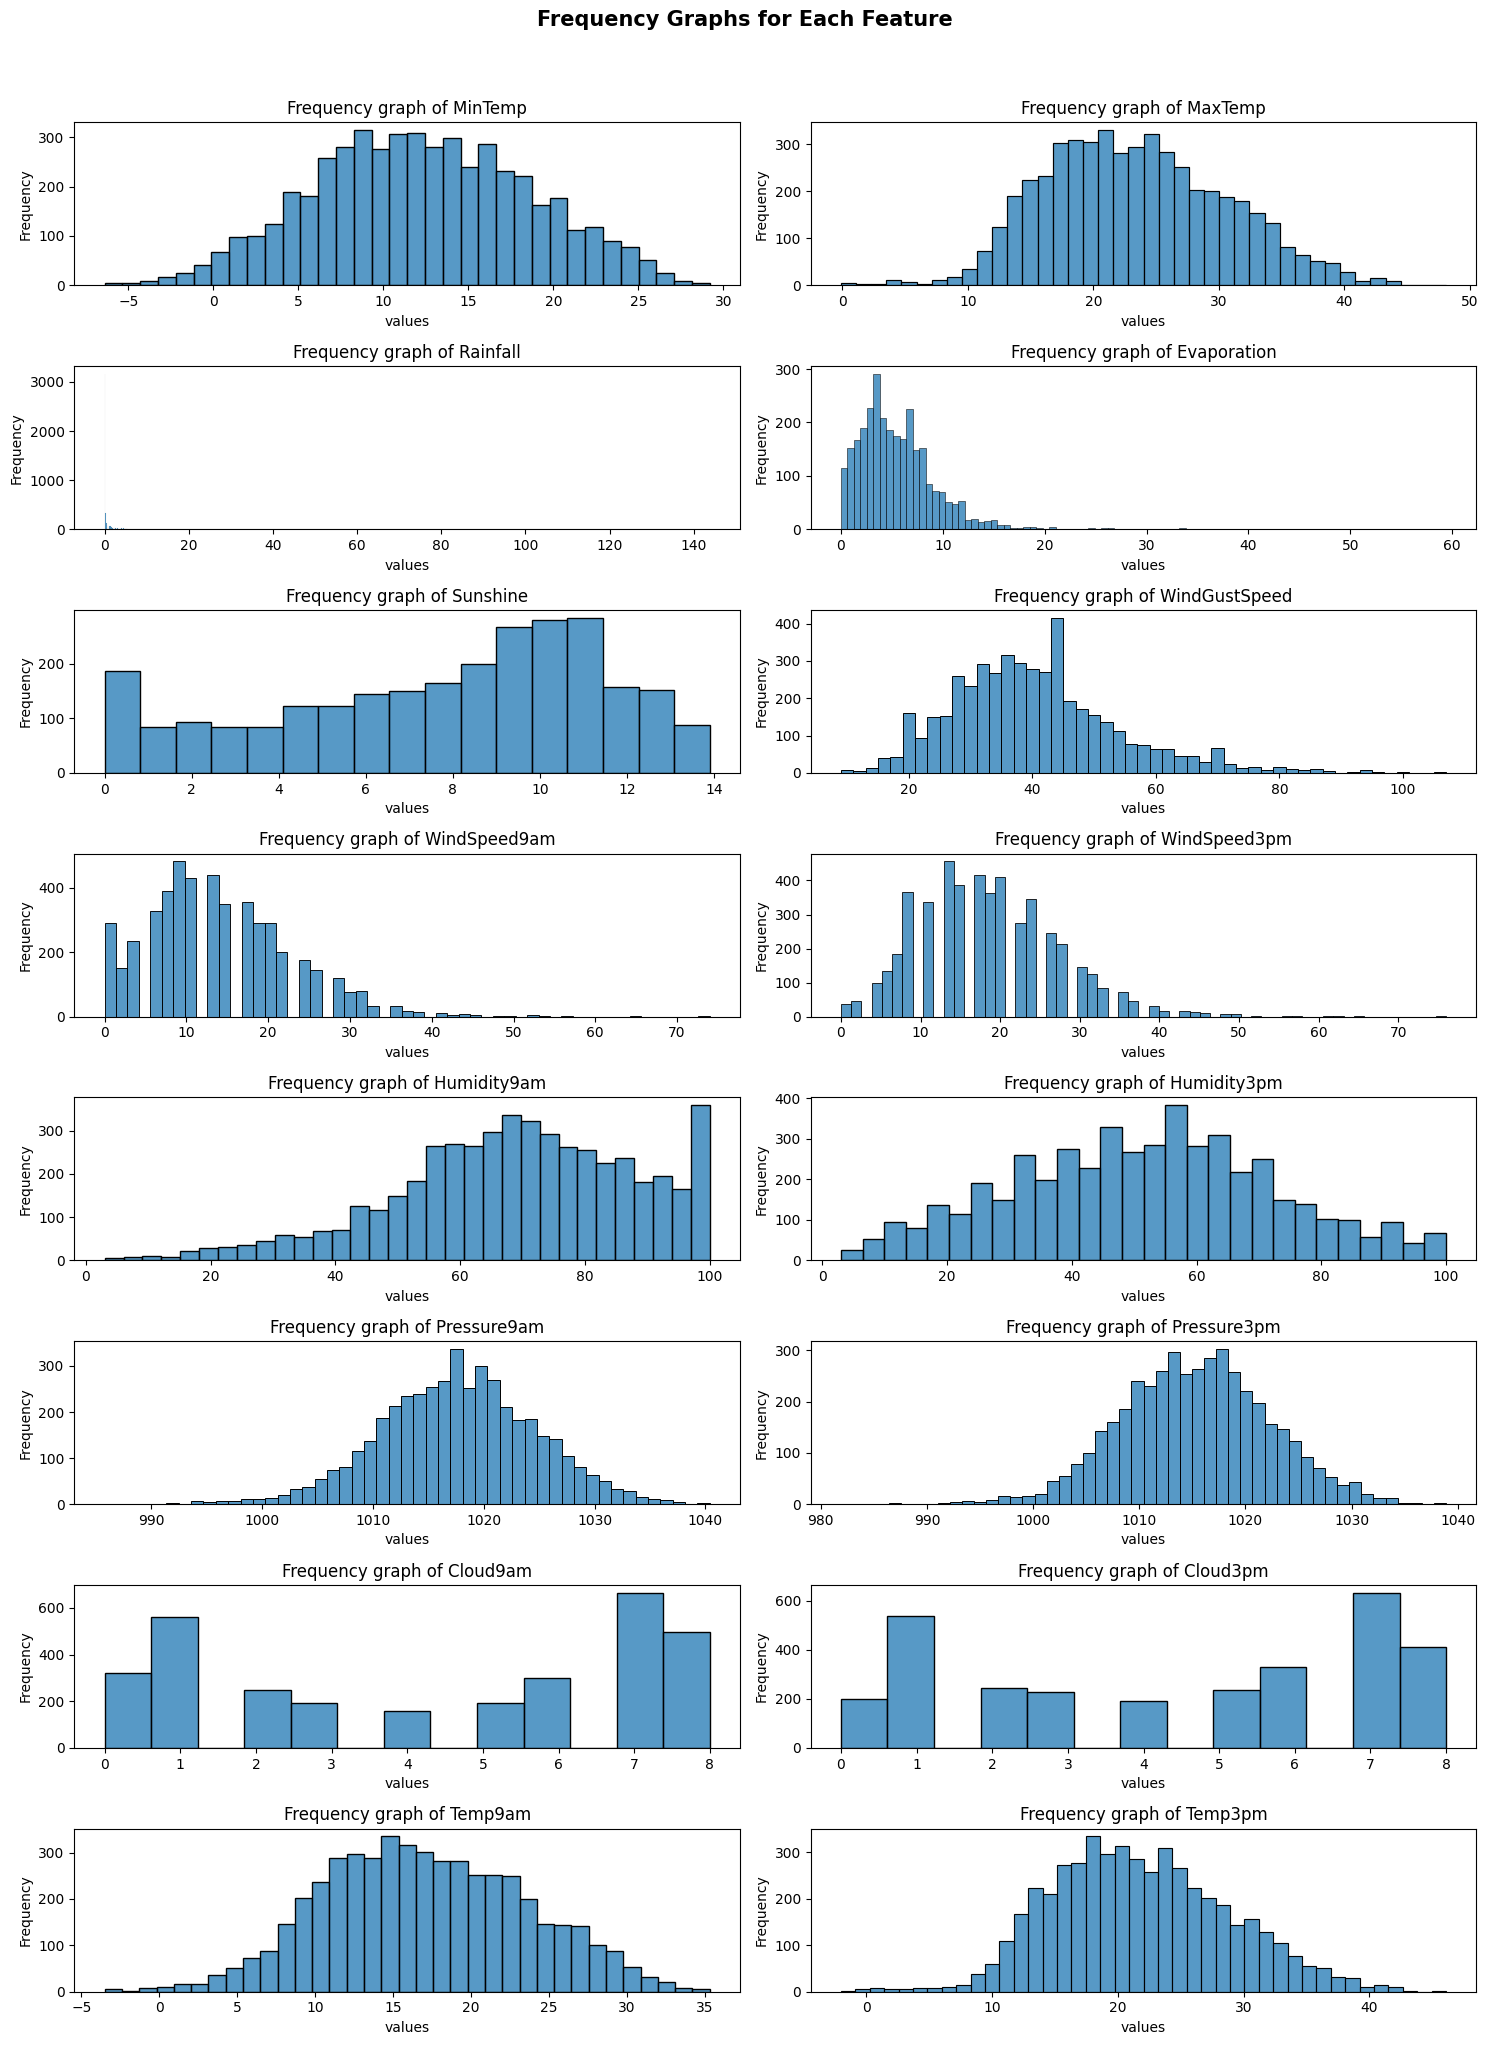

In [12]:
# graph of frequencies of each numerical column


fig, axes = plt.subplots(len(num_cols)//2, 2, figsize=(15,20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data = sample_df, x = col, ax=axes[i])
    axes[i].set_title(f'Frequency graph of {col}')
    axes[i].set_xlabel('values')
    axes[i].set_ylabel('Frequency')
    # axes[i].text(0.95, 0.95, f'Max: {rawdf[col].max()}\nMin: {rawdf[col].min()}',
    #              verticalalignment='top',
    #              horizontalalignment='right')
    
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle('Frequency Graphs for Each Feature', y=1.02, fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


In [13]:
for cols in skewness_value:
    if abs(skewness_value[cols]) > 0.5:
        print(f'{cols}: {skewness_value[cols]}')
    

Rainfall: 9.88806106787276
Evaporation: 3.7500623172248293
Sunshine: -0.5050335586887441
WindGustSpeed: 0.8714575776232963
WindSpeed9am: 0.7745171723649928
WindSpeed3pm: 0.6314069150902173


# Correlation Matrix

In [14]:
print(sample_df['RainTomorrow'].unique())
print(sample_df['RainToday'].unique())

['No' 'Yes']
['No' 'Yes']


In [15]:
mapper = {
    'No': 0,
    'Yes':1
}

In [16]:
rawdf['RainTomorrow'] = rawdf['RainTomorrow'].map(mapper)
rawdf['RainToday'] = rawdf['RainToday'].map(mapper)

In [17]:
print(rawdf['RainTomorrow'].value_counts())
print(rawdf['RainToday'].value_counts())

RainTomorrow
0    109586
1     31201
Name: count, dtype: int64
RainToday
0    109332
1     31455
Name: count, dtype: int64


In [18]:
num_cols = rawdf.select_dtypes(include='number').columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [19]:
corr_mat = rawdf[num_cols].corr()
corr_mat['RainTomorrow'].sort_values(ascending=False)

RainTomorrow     1.000000
Humidity3pm      0.447834
Cloud3pm         0.382418
Cloud9am         0.316592
RainToday        0.313097
Humidity9am      0.257727
Rainfall         0.239032
WindGustSpeed    0.234285
WindSpeed9am     0.089803
WindSpeed3pm     0.086762
MinTemp          0.084322
Temp9am         -0.025447
Evaporation     -0.119133
MaxTemp         -0.159405
Temp3pm         -0.192747
Pressure3pm     -0.228192
Pressure9am     -0.248253
Sunshine        -0.451820
Name: RainTomorrow, dtype: float64

# EDA & Data Visualization

<Axes: >

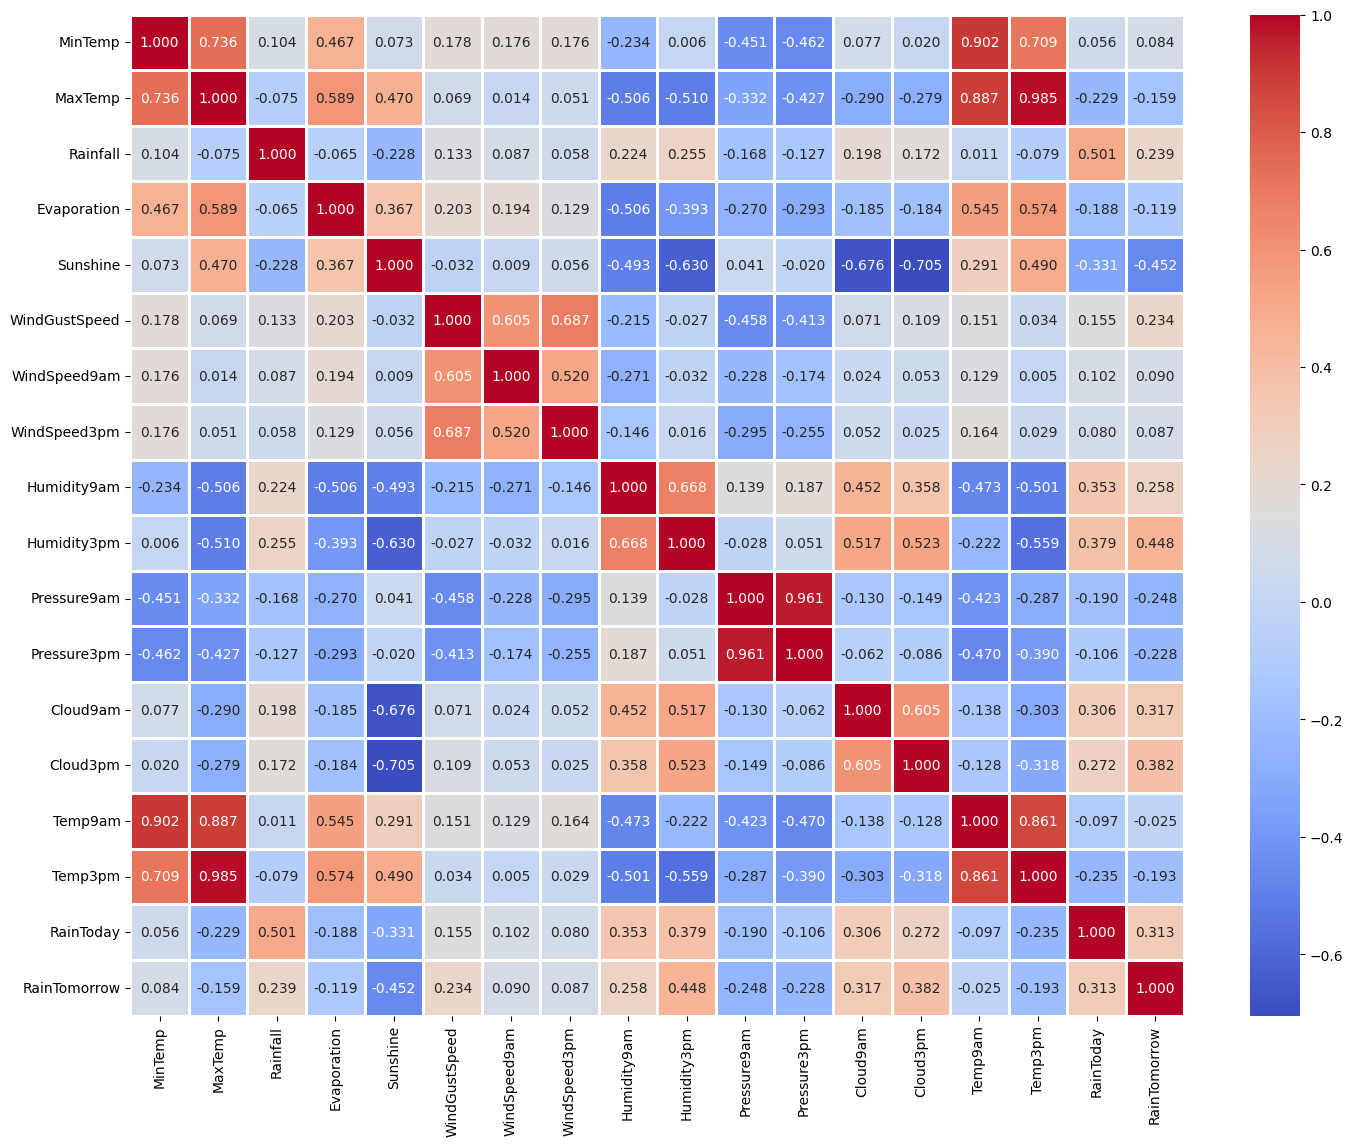

In [20]:
plt.figure(figsize=(17,13))
# annot=True displays the actual correlation coefficients in the cells
# fmt=".2f" formats the numbers to 2 decimal places
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='coolwarm', linewidths=1.0)

In [21]:
for i, x in corr_mat['RainTomorrow'].items():
    print(i,x)

MinTemp 0.0843224591230754
MaxTemp -0.15940537274012676
Rainfall 0.23903180145061992
Evaporation -0.11913309110521268
Sunshine -0.4518195495945784
WindGustSpeed 0.2342846857207282
WindSpeed9am 0.0898033706005351
WindSpeed3pm 0.08676214043872942
Humidity9am 0.2577272149934941
Humidity3pm 0.4478335286075184
Pressure9am -0.24825260294467616
Pressure3pm -0.22819191281350817
Cloud9am 0.3165924106566437
Cloud3pm 0.3824177238602695
Temp9am -0.025446763318813157
Temp3pm -0.19274687628154408
RainToday 0.31309674550896077
RainTomorrow 1.0


In [22]:
strong_corr = corr_mat['RainTomorrow'][corr_mat['RainTomorrow'].abs() > .3]
print(strong_corr)

Sunshine       -0.451820
Humidity3pm     0.447834
Cloud9am        0.316592
Cloud3pm        0.382418
RainToday       0.313097
RainTomorrow    1.000000
Name: RainTomorrow, dtype: float64


# Box Plot

### What is a Box Plot and what does it do?

A **Box Plot** (also called a Box-and-Whisker Plot) is a visual tool used to show the distribution of numerical data and identify **outliers**. It summarizes a dataset using five key statistics (the "five-number summary"):

```text
       Outlier          Minimum          Q1      Median      Q3          Maximum          Outliers
          o ──────────────|──────────────[═══════════|═══════]──────────────|────────────── o   o
                                         |<--- IQR (50%) --->|
```

* **Median (Q2 / 50th Percentile):** The middle line inside the box. 50% of the data lies below this value, and 50% lies above.
* **First Quartile (Q1 / 25th Percentile):** The left/bottom edge of the box. 25% of the data lies below this.
* **Third Quartile (Q3 / 75th Percentile):** The right/top edge of the box. 75% of the data lies below this.
* **Interquartile Range (IQR):** The width of the box ($IQR = Q3 - Q1$). It represents the middle 50% of your data.
* **Whiskers (the lines):** Extend from the box to show the range of the rest of the data. They extend up to $1.5 \times IQR$ from the box edges.
* **Outliers (individual dots):** Any data point that falls *beyond* the whiskers is flagged as an outlier (extreme value).

---


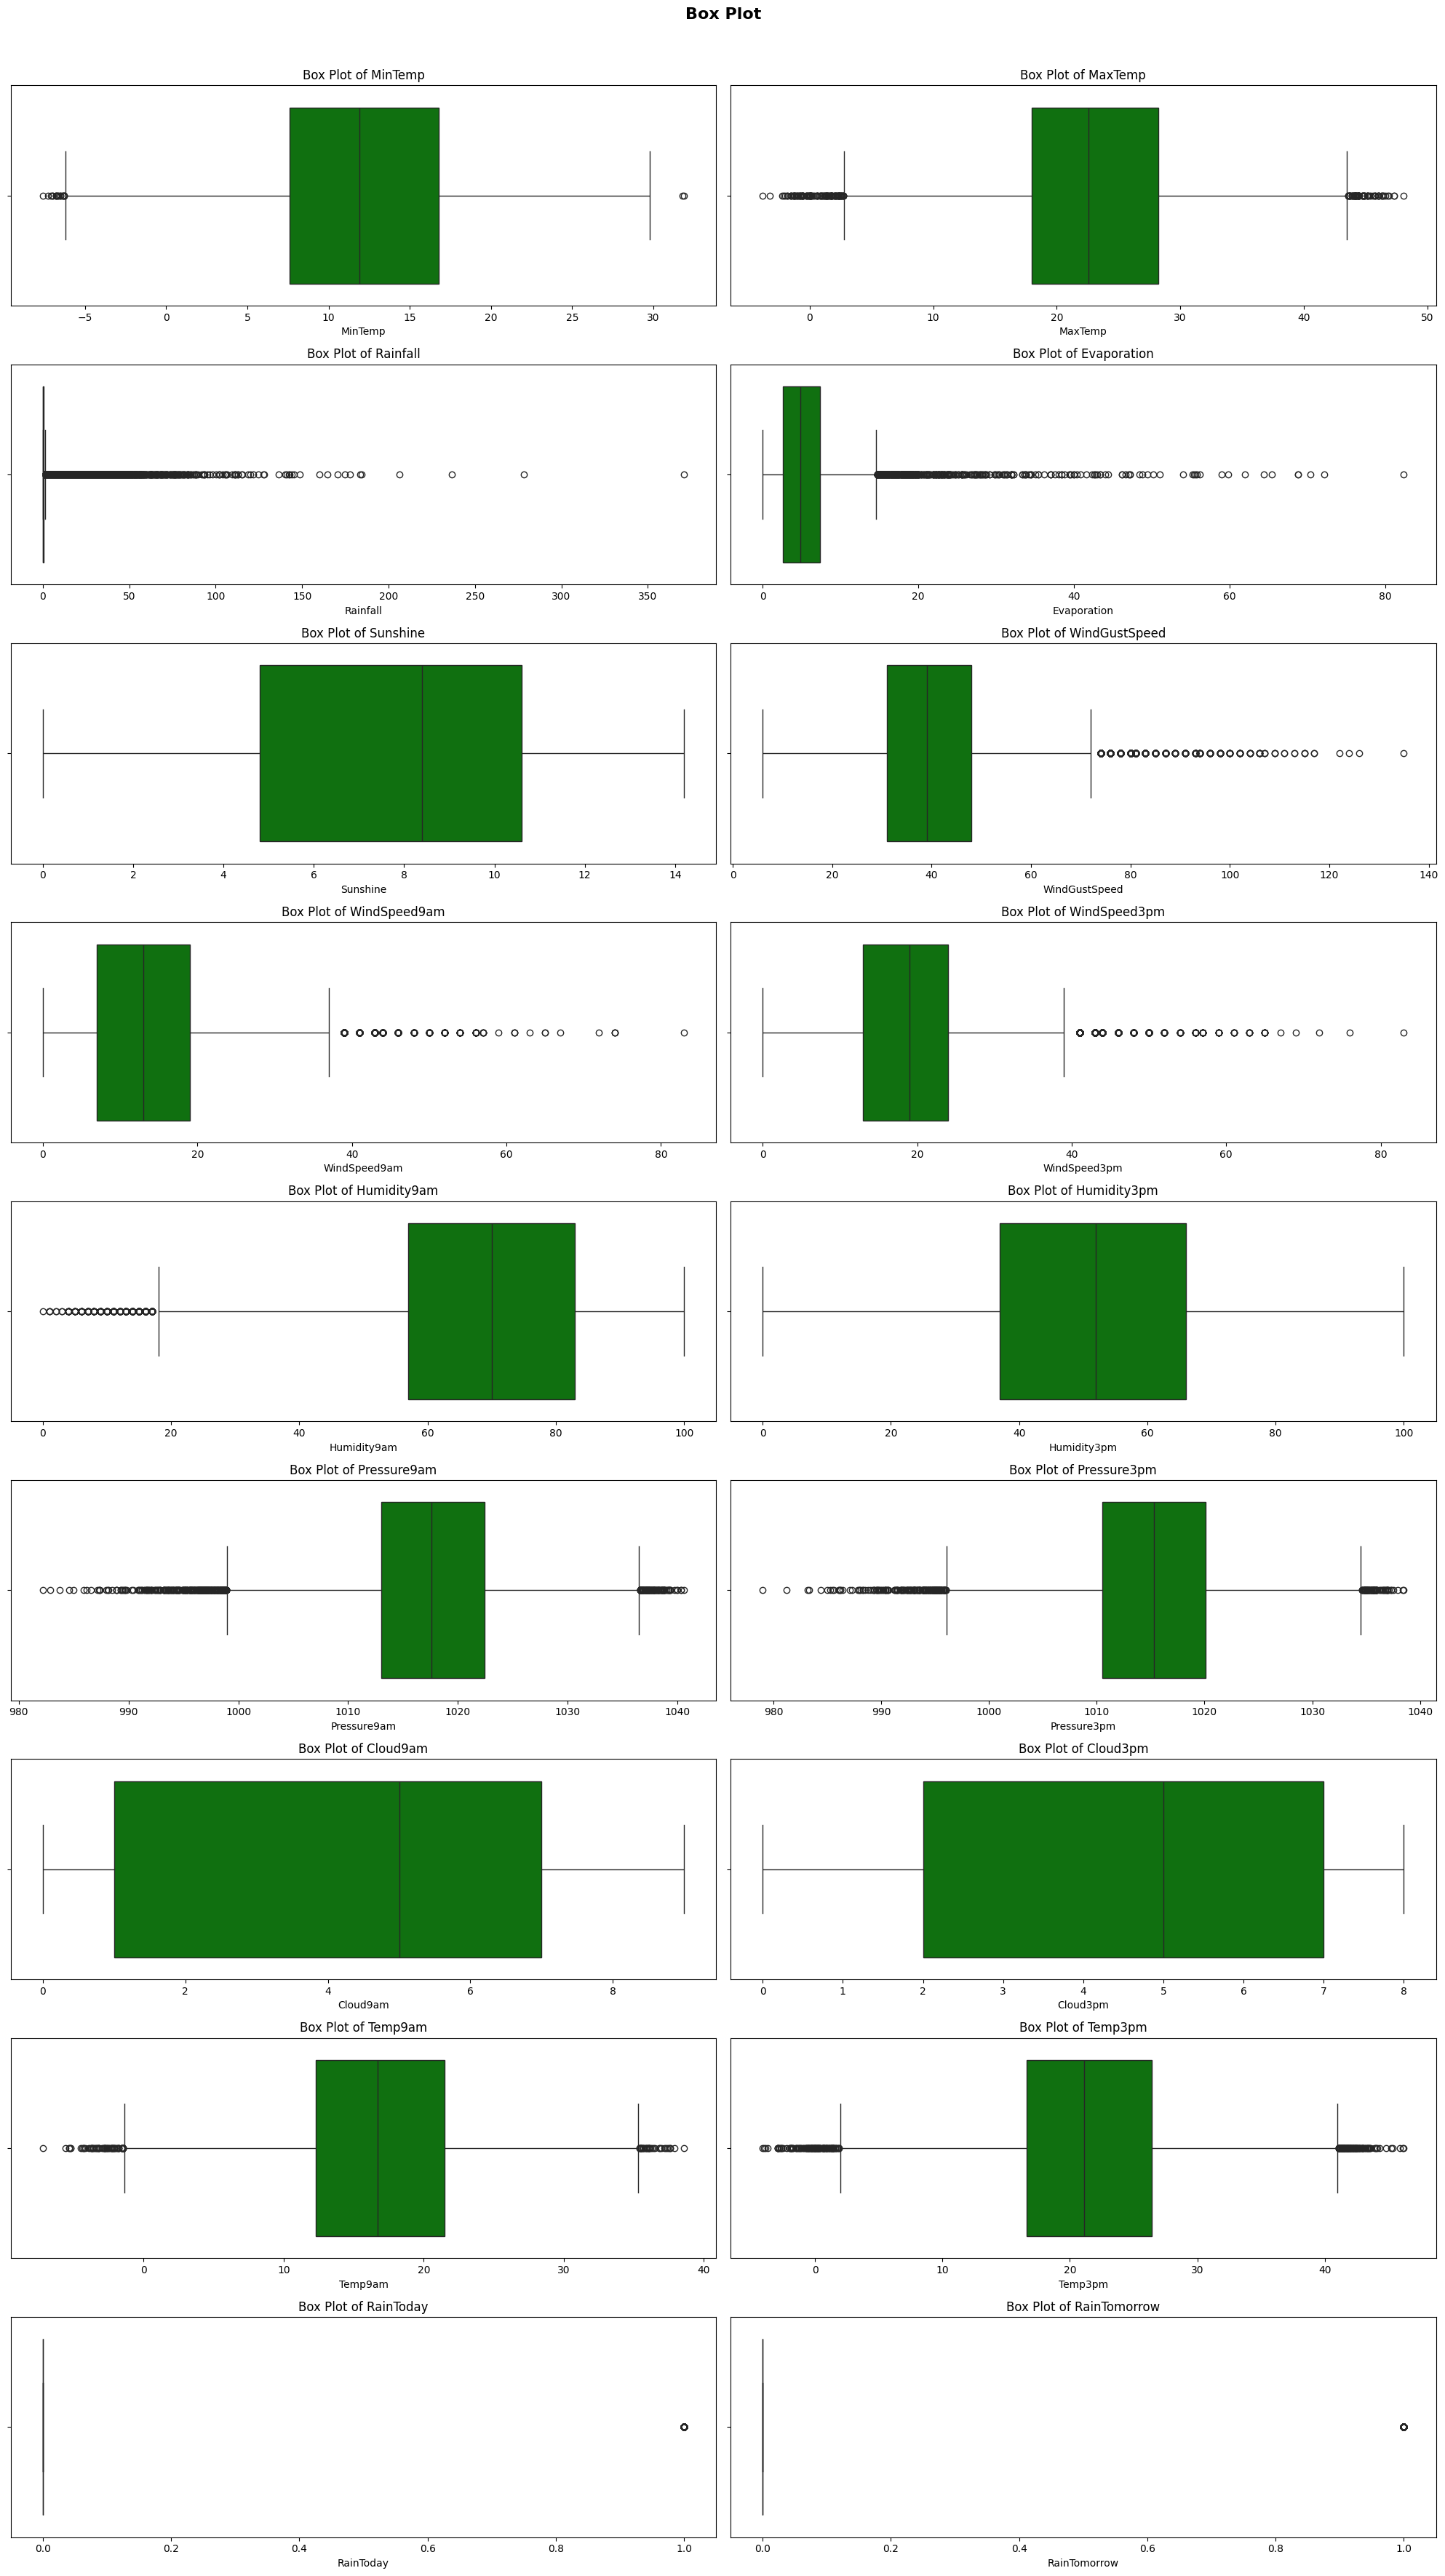

In [32]:
n_cols = 2
n_rows = (len(num_cols) + n_cols -1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20,35))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=rawdf.sample(50000), x=col, ax=axes[i], color='green')
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel(f'{col}')
    # axes[i].set_ylabel(f'RainTomorrow')
    
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle('Box Plot', fontsize=16, y=1.01, weight='bold')
plt.tight_layout()
plt.show()

### How to Interpret Each Box Plot

Look for **3 things** in every box plot:

#### 1. 🔵 The Box (Middle 50% of data)
- A **wide box** means the data is spread out (high variability).
- A **narrow box** means most values are concentrated (low variability).

#### 2. 📍 The Median Line (inside the box)
- If the median line is **centered** in the box → symmetric distribution.
- If the median line is **pushed to the left** → right-skewed (confirms what we found earlier).
- If the median line is **pushed to the right** → left-skewed.

#### 3. ⚫ The Dots (Outliers)
- Individual dots beyond the whiskers are **outliers**.
- **Many dots on one side** = highly skewed data with extreme values.
- **Few or no dots** = clean data, no extreme values.

---

In [34]:
outlier_counts = {}
for col in num_cols:
    Q1 = rawdf[col].quantile(0.25)
    Q3 = rawdf[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((rawdf[col] < lower_bound) | (rawdf[col] > upper_bound)).sum()
    outlier_counts[col] = n_outliers
    
outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print(f'Outlier counts per features:\n\n{outlier_series}')

Outlier counts per features:

RainToday        31455
RainTomorrow     31201
Rainfall         25228
WindGustSpeed     2962
WindSpeed3pm      2420
Evaporation       1947
WindSpeed9am      1715
Humidity9am       1414
Pressure9am       1269
Pressure3pm        899
Temp3pm            711
MaxTemp            387
Temp9am            245
MinTemp             61
Cloud3pm             0
Cloud9am             0
Sunshine             0
Humidity3pm          0
dtype: int64
